# 🚀 Project Overview | 🏗️ XTALLET - Advanced Build Activity

Reproduce the RAGAS Synthetic Data Generation Steps, replacing the traditional Knowledge Graph with a LangGraph Agent Graph.

Key Features:
- Uses the Evol Instruct method for synthetic data generation.

- Final output includes:
  - List(dict): Evolved Questions with IDs and Evolution Types.
  - List(dict): Question IDs with Answers linked to Evolved Questions.
  - List(dict): Question IDs with relevant Context(s) for each Evolved Question.

- Supports:
  - Simple Evolution
  - Multi-Context Evolution
  - Reasoning Evolution

- Input: List of LangChain Documents.

✅ The project implements a LangGraph-based flow to manage question evolution, context retrieval, and answer generation as interconnected nodes.<br>
✅ The Evol-Instruct technique is used to transform base questions into evolved variations (simple, reasoning, multi-context).<br>
✅ The graph output contains structured lists of evolved questions, their IDs, evolution types, corresponding answers, and relevant contexts.<br>
✅ Three evolution types are randomly selected and applied, ensuring coverage of all requested question evolution scenarios.<br>
✅ The pipeline starts by loading LangChain documents (PDFs), splitting them into chunks, and feeding them into the graph as input.<br>

In [1]:
# -------------------------------
# 📥 NLTK Setup: Download Tokenizers & Taggers  | 🏗️ XTALLET
# -------------------------------

import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /home/xtallet/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/xtallet/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [2]:
# -------------------------------
# 🔐 LangChain Setup: Enable Tracing & Set API Key  | 🏗️ XTALLET
# -------------------------------

import os
import getpass

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangChain API Key:")

In [3]:
# -------------------------------
# 🏷️ LangChain Project Naming (UUID for Tracking)  | 🏗️ XTALLET
# -------------------------------

from uuid import uuid4

os.environ["LANGCHAIN_PROJECT"] = f"AIM - SDG - AdvancedBuild - {uuid4().hex[0:8]}"

In [4]:
# -------------------------------
# 🔑 OpenAI Setup: Set API Key Securely  | 🏗️ XTALLET
# -------------------------------

os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

In [5]:
# -------------------------------
# 📂 Load PDF Documents from Directory  | 🏗️ XTALLET
# -------------------------------

from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader


path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()
docs = docs[:2]
print(f"📄 Total documents (PDF pages): {len(docs)}")

📄 Total documents (PDF pages): 2


In [6]:
rag_documents = docs

In [7]:
# -------------------------------
# ✂️ Split Documents into Text Chunks & Print Stats  | 🏗️ XTALLET
# -------------------------------

from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)
print(f"🧩 Total text chunks after splitting: {len(rag_documents)}")

from collections import Counter
source_counts = Counter(doc.metadata["source"] for doc in rag_documents)
print("\n📊 Chunks per document:")
for src, count in source_counts.items():
    print(f"- {src}: {count} chunks")

🧩 Total text chunks after splitting: 16

📊 Chunks per document:
- data/Academic_Calenders_Cost_of_Attendance_and_Packaging.pdf: 16 chunks


In [8]:
# -------------------------------
# 🧬 Initialize OpenAI Embeddings Model  | 🏗️ XTALLET
# -------------------------------

from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [9]:
# -------------------------------
# 🗃️ Create Qdrant Vector Store from Documents  | 🏗️ XTALLET
# -------------------------------

from langchain_community.vectorstores import Qdrant

vectorstore = Qdrant.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="Loan RAG"
)

In [10]:
# -------------------------------
# 🔍 Setup Retriever from Vector Store (Top 10 Results)  | 🏗️ XTALLET
# -------------------------------

retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

In [11]:
# -------------------------------
# 📦 Import Core Libraries & Setup Typing  | 🏗️ XTALLET
# -------------------------------

from langchain_core.documents import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.vectorstores import FAISS
from langchain.embeddings import OpenAIEmbeddings
from langchain.chat_models import ChatOpenAI
from langchain.chains import LLMChain
from langchain.prompts import PromptTemplate

from langgraph.graph import StateGraph
from typing import List, Dict, TypedDict
import uuid
import random

In [12]:
# -------------------------------
# 🧠 Define State  | 🏗️ XTALLET
# -------------------------------

class GraphState(TypedDict):
    documents: List[Document]
    evolved_questions: List[Dict]
    contexts: List[Dict]
    answers: List[Dict]

In [13]:
# -------------------------------
# 🧩 Evol-Instruct Prompt & Chain  | 🏗️ XTALLET
# -------------------------------

evol_prompt = PromptTemplate.from_template("""
You are a helpful assistant that evolves questions for synthetic data generation.

Original Question:
{question}

Evolution Type: {evolution_type}

Please return ONLY the evolved question, nothing else.
""")

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.7)
evol_chain = LLMChain(llm=llm, prompt=evol_prompt)

/tmp/ipykernel_40965/298675874.py:16: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.7)
/tmp/ipykernel_40965/298675874.py:17: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  evol_chain = LLMChain(llm=llm, prompt=evol_prompt)


In [14]:
# -------------------------------
# 🟡 Node: Generate Base Questions from Documents  | 🏗️ XTALLET
# -------------------------------

question_gen_prompt = PromptTemplate.from_template("""
You are an expert assistant. Given the following document content, generate 3 high-quality questions that could be asked about it.

Content:
{document}

Questions:
""")

question_gen_chain = LLMChain(llm=llm, prompt=question_gen_prompt)

def generate_questions_from_docs(state: GraphState) -> List[str]:
    questions = []
    for doc in state["documents"]:
        result = question_gen_chain.run(document=doc.page_content[:1000])  # truncated to avoid token limit
        # Basic cleaning of generated text
        qs = [q.strip("-• ").strip() for q in result.split("\n") if q.strip()]
        questions.extend(qs[:3])  # maximum 3 questions per document
    return questions

In [15]:
# -------------------------------
# 1️⃣ Node: Evolve Questions  | 🏗️ XTALLET
# -------------------------------

def evolve_questions(state: GraphState) -> GraphState:
    base_questions = generate_questions_from_docs(state)
    #print(f'base_questions : {base_questions}')
    evolution_types = ["simple", "reasoning", "multi-context"]
    evolved = []

    for q in base_questions:
        evo_type = random.choice(evolution_types)
        result = evol_chain.run(question=q, evolution_type=evo_type)
        evolved.append({
            "id": str(uuid.uuid4()),
            "original_question": q,
            "evolved_question": result.strip(),
            "evolution_type": evo_type
        })

    return {**state, "evolved_questions": evolved}

In [16]:
# -------------------------------
# 2️⃣ Node: Context Retriever  | 🏗️ XTALLET
# -------------------------------

def retrieve_contexts(state: GraphState) -> GraphState:
    splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    all_chunks = splitter.split_documents(state["documents"])

    results = []
    for q in state["evolved_questions"]:
        docs = retriever.get_relevant_documents(q["evolved_question"])
        results.append({
            "id": q["id"],
            "contexts": [doc.page_content for doc in docs]
        })

    return {**state, "contexts": results}

In [17]:
# -------------------------------
# 3️⃣ Node: Answer Generator  | 🏗️ XTALLET
# -------------------------------

answer_prompt = PromptTemplate.from_template("""
You are an expert assistant. Given the question and context, provide a complete, accurate answer.

Question: {question}

Context:
{context}

Answer:
""")
answer_chain = LLMChain(llm=llm, prompt=answer_prompt)

def generate_answers(state: GraphState) -> GraphState:
    answers = []
    for q in state["evolved_questions"]:
        ctx_entry = next(c for c in state["contexts"] if c["id"] == q["id"])
        context_text = "\n\n".join(ctx_entry["contexts"][:3])  # Limit context for token safety
        answer = answer_chain.run(question=q["evolved_question"], context=context_text)
        answers.append({"id": q["id"], "answer": answer.strip()})

    return {**state, "answers": answers}

In [18]:
# -------------------------------
# 🧠 Build LangGraph  | 🏗️ XTALLET
# -------------------------------

graph = StateGraph(GraphState)

graph.add_node("evolve_questions", evolve_questions)
graph.add_node("retrieve_contexts", retrieve_contexts)
graph.add_node("generate_answers", generate_answers)

graph.set_entry_point("evolve_questions")
graph.add_edge("evolve_questions", "retrieve_contexts")
graph.add_edge("retrieve_contexts", "generate_answers")
graph.set_finish_point("generate_answers")

compiled_graph = graph.compile()

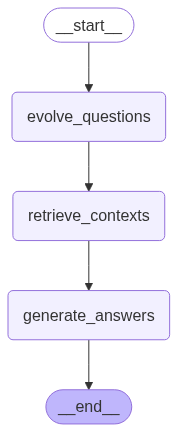

In [19]:
# -------------------------------
# 🔍 Inspect Compiled Graph Structure | 🏗️ XTALLET - Graph Visualization
# -------------------------------

compiled_graph

In [20]:
# -------------------------------
# 🚀 Run Graph  | 🏗️ XTALLET
# -------------------------------

initial_state = {"documents": docs}
final_state = compiled_graph.invoke(initial_state)

/tmp/ipykernel_40965/3099877858.py:19: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  result = question_gen_chain.run(document=doc.page_content[:1000])  # truncated to avoid token limit
/tmp/ipykernel_40965/3873413470.py:11: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  docs = retriever.get_relevant_documents(q["evolved_question"])


In [21]:
# -------------------------------
# ✅ Outputs  | 🏗️ XTALLET
# -------------------------------

from pprint import pprint

print("\n📌 Evolved Questions:")
pprint(final_state["evolved_questions"])

print("\n📌 Contexts:")
pprint(final_state["contexts"])

print("\n📌 Answers:")
pprint(final_state["answers"])


📌 Evolved Questions:
[{'evolution_type': 'multi-context',
  'evolved_question': '1. What are the key components related to Title IV '
                      'student financial aid programs discussed in Volume 3 of '
                      'the Federal Student Aid Handbook, and how do these '
                      'components vary across different types of '
                      'institutions?  \n'
                      '2. How are the Title IV student financial aid program '
                      'components outlined in Volume 3 of the Federal Student '
                      'Aid Handbook applied in both public and private '
                      'educational institutions?  \n'
                      '3. In the context of Volume 3 of the Federal Student '
                      'Aid Handbook, what are the essential elements of Title '
                      'IV student financial aid programs, and how do they '
                      'impact student eligibility and institutional '
         

In [23]:
# -------------------------------
# 📊 Convert Final State to Pandas DataFrame  | 🏗️ XTALLET
# -------------------------------

import pandas as pd

questions = final_state["evolved_questions"]
contexts = final_state["contexts"]
answers = final_state["answers"]

# Convert to dicts indexed by ID
ctx_dict = {c["id"]: c["contexts"] for c in contexts}
ans_dict = {a["id"]: a["answer"] for a in answers}

# Combine all in a list of rows
rows = []
for q in questions:
    qid = q["id"]
    rows.append({
        "id": qid,
        "original_question": q["original_question"],
        "evolved_question": q["evolved_question"],
        "evolution_type": q["evolution_type"],
        "contexts": "\n\n".join(ctx_dict.get(qid, [])),
        "answer": ans_dict.get(qid, "")
    })

# Create the Dataframe
df = pd.DataFrame(rows)

# Export Dataframe
print(df.columns.tolist())
#df.to_csv("synthetic_rag_dataset.csv", index=False)

['id', 'original_question', 'evolved_question', 'evolution_type', 'contexts', 'answer']


In [25]:
# -------------------------------
# 🛠️ LangSmith Instrumentation
# -------------------------------

from langsmith import Client

client = Client()

dataset_name = "Loan Synthetic Data Using LangGraph Agent Graph"

langsmith_dataset = client.create_dataset(
    dataset_name=dataset_name,
    description="Loan Synthetic Data Using LangGraph Agent Graph instead of RAGAS"
)

In [26]:
# -------------------------------
# 📤 Upload Evaluation Examples to LangSmith  | 🏗️ XTALLET
# -------------------------------

for data_row in df.iterrows():
  client.create_example(
      inputs={
          "question": data_row[1]["evolved_question"]
      },
      outputs={
          "answer": data_row[1]["answer"]
      },
      metadata={
          "context": data_row[1]["contexts"]
      },
      dataset_id=langsmith_dataset.id
  )

In [27]:
# -------------------------------
# 💬 Define RAG QA Prompt Template  | 🏗️ XTALLET
# -------------------------------

from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

Context: {context}
Question: {question}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

In [28]:
# -------------------------------
# 🤖 Initialize Chat LLM Model  | 🏗️ XTALLET
# -------------------------------

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-mini")

In [29]:
# -------------------------------
# 🔗 Build RAG QA Chain Pipeline  | 🏗️ XTALLET
# -------------------------------

from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain.schema import StrOutputParser

rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | rag_prompt | llm | StrOutputParser()
)

In [30]:
# -------------------------------
# ⚖️ Initialize Evaluation LLM  | 🏗️ XTALLET
# -------------------------------

eval_llm = ChatOpenAI(model="gpt-4.1")

In [31]:
# -------------------------------
# 🧪 Setup LangSmith Evaluators  | 🏗️ XTALLET
# -------------------------------

from langsmith.evaluation import LangChainStringEvaluator, evaluate

qa_evaluator = LangChainStringEvaluator("qa", config={"llm" : eval_llm})

labeled_helpfulness_evaluator = LangChainStringEvaluator(
    "labeled_criteria",
    config={
        "criteria": {
            "helpfulness": (
                "Is this submission helpful to the user,"
                " taking into account the correct reference answer?"
            )
        },
        "llm" : eval_llm
    },
    prepare_data=lambda run, example: {
        "prediction": run.outputs["output"],
        "reference": example.outputs["answer"],
        "input": example.inputs["question"],
    }
)

empathy_evaluator = LangChainStringEvaluator(
    "criteria",
    config={
        "criteria": {
            "empathy": "Is this response empathetic? Does it make the user feel like they are being heard?",
        },
        "llm" : eval_llm
    }
)

In [32]:
# -------------------------------
# 🚦 Run LangSmith Evaluation | 🏗️ XTALLET
# -------------------------------

evaluate(
    rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        empathy_evaluator
    ],
    metadata={"revision_id": "default_chain_init"},
)

View the evaluation results for experiment: 'artistic-dad-9' at:
https://smith.langchain.com/o/c21c7da9-346c-4a28-b19c-bb6d2faffe60/datasets/6ea9b5f5-2dd3-46ae-aaff-971b9faf49a0/compare?selectedSessions=755d9c58-4866-4cc5-aa11-88e680d9a46b




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.correctness,feedback.helpfulness,feedback.empathy,execution_time,example_id,id
0,3. How can different types of educational inst...,Based on the provided context:\n\nEducational ...,None,"Different types of educational institutions, s...",1,1,0,11.902695,4f6f6d91-e0a5-4ccc-96a2-e2338b35083e,ae96e535-0bb5-45e3-a9d0-7bf392f70c7f
1,2. How does the definition of an academic year...,"According to the context provided, for Title I...",None,"According to Title IV requirements, the defini...",1,1,0,2.562697,09db0477-c564-4c1f-b674-a6bbe09e7973,a017e9ee-8fad-4c54-a641-8a98dcb2d659
2,1. How do criteria for defining the academic y...,I don't know.,None,The criteria for defining the academic year va...,0,0,0,1.283516,da3ae299-dcee-4df0-815b-a5bb4c0b354f,d426940f-914d-4c49-9b95-f6f077ffafa1
3,3. How do the academic calendar and payment pe...,I don't know.,None,The academic calendar and payment period signi...,0,0,0,1.213753,6ef09dde-ea47-44d6-8a00-fb52c5444de9,9a3d2f4a-8693-44b9-8875-beb6fec2419b
4,"2. How are the terms ""we,"" ""you,"" and ""school""...",Based on the provided context from Volume 3 of...,None,In Volume 3 of the Federal Student Aid (FSA) H...,1,1,0,4.043226,ff35f343-8255-41d7-bdc3-d28f13048cec,d99407bf-cb39-4084-a632-94e1ca5cf4e2
5,1. What are the key components related to Titl...,"1. Based on the provided context, Volume 3 of ...",None,Certainly! Below is a comprehensive answer add...,1,0,0,5.266884,c45ebea1-d849-47ec-9fb1-8e778224b088,5b109a96-4ad8-4c38-82ae-9c27505f8325


In [33]:
# -------------------------------
# 🚀 Dope-ifying Our Application
# -------------------------------

EMPATHY_RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

You must answer the question using empathy and kindness, and make sure the user feels heard.

Context: {context}
Question: {question}
"""

empathy_rag_prompt = ChatPromptTemplate.from_template(EMPATHY_RAG_PROMPT)

In [34]:
rag_documents = docs

In [35]:
# -------------------------------
# ✂️ Text Splitting for Chunking | 🏗️ XTALLET - Dope-ifying Our Application
# -------------------------------

from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

In [36]:
# -------------------------------
# 🧠 Embeddings Setup | 🏗️ XTALLET - Dope-ifying Our Application
# -------------------------------

from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

In [37]:
# -------------------------------
# 🗄️ Vector Store Initialization | 🏗️ XTALLET - Dope-ifying Our Application
# -------------------------------

vectorstore = Qdrant.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="Loan Data for RAG"
)

In [38]:
# -------------------------------
# 🔍 Retriever Setup | 🏗️ XTALLET - Dope-ifying Our Application
# ------------------------------

retriever = vectorstore.as_retriever()

In [39]:
# -------------------------------
# 🤖 Empathy RAG Chain Construction | 🏗️ XTALLET - Dope-ifying Our Application
# -------------------------------

empathy_rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | empathy_rag_prompt | llm | StrOutputParser()
)

In [40]:
# -------------------------------
# ✅ Run Evaluation on Empathy RAG Chain | 🏗️ XTALLET - Dope-ifying Our Application
# -------------------------------

evaluate(
    empathy_rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        empathy_evaluator
    ],
    metadata={"revision_id": "empathy_rag_chain"},
)

View the evaluation results for experiment: 'definite-knife-17' at:
https://smith.langchain.com/o/c21c7da9-346c-4a28-b19c-bb6d2faffe60/datasets/6ea9b5f5-2dd3-46ae-aaff-971b9faf49a0/compare?selectedSessions=2f36f92c-7244-42c9-8241-8e5d3e0fd0ef




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.correctness,feedback.helpfulness,feedback.empathy,execution_time,example_id,id
0,3. How can different types of educational inst...,Thank you for your thoughtful question! Based ...,None,"Different types of educational institutions, s...",1,1,1,4.666856,4f6f6d91-e0a5-4ccc-96a2-e2338b35083e,2aa3612a-adc7-4ac2-aed1-e21131e92007
1,2. How does the definition of an academic year...,Thank you for your thoughtful question. Based ...,None,"According to Title IV requirements, the defini...",1,1,1,3.333755,09db0477-c564-4c1f-b674-a6bbe09e7973,0d849bb9-2e72-4a21-8894-b7f8e90be2ec
2,1. How do criteria for defining the academic y...,Thank you for your thoughtful question. Based ...,None,The criteria for defining the academic year va...,1,1,1,3.486391,da3ae299-dcee-4df0-815b-a5bb4c0b354f,f8a9be05-c768-4587-8cf7-0dc8d16fa4e1
3,3. How do the academic calendar and payment pe...,Thank you for your thoughtful question. Based ...,None,The academic calendar and payment period signi...,1,1,1,4.297392,6ef09dde-ea47-44d6-8a00-fb52c5444de9,dfb09a40-6feb-4a22-b4c3-5716b4a9149e
4,"2. How are the terms ""we,"" ""you,"" and ""school""...",Thank you for your thoughtful question. Based ...,None,In Volume 3 of the Federal Student Aid (FSA) H...,1,1,1,4.079768,ff35f343-8255-41d7-bdc3-d28f13048cec,d895a755-4635-4dec-8183-ce96160fc98b
5,1. What are the key components related to Titl...,Thank you for your thoughtful questions. You’r...,None,Certainly! Below is a comprehensive answer add...,1,1,1,9.625263,c45ebea1-d849-47ec-9fb1-8e778224b088,c696b682-6dbc-4e57-b706-845597a9dd48


#### Screenshots

In the screenshots below we can see similar results to the main notebook.<br>
The `Correctness` has improved, because the number of answers marked as correct increased in the second evaluation.
This is due to using a better embedding model and a larger chunk size to get better context.<br>

The `Empathy` has also improved because scores increased significantly in the second evaluation.<br>

The `Helpfulness` has also improved significantly.<br>

In the second evaluation, the number of correct answers increased due to a better embedding model and larger chunk sizes, which provided more relevant and complete context.<br> 
This led to more accurate responses.<br> 
The switch to an empathy-focused prompt did not negatively affect correctness.<br> 
Helpfulness scores generally improved, likely because of the richer context and more user-focused responses.<br> 
The empathy prompt encouraged more supportive and understanding language. As a result, empathy scores increased significantly, as evaluators noticed more empathetic phrasing and tone in the answers.<br> 
Overall, both accuracy and user experience improved in the second evaluation.

 - This screenshot shows both evaluations comparisson
<img src="screenshots/langraph_ab_1.png" alt="Loan Synthetic Data" width="1200"/>

 - This screenshot shows the details about the Evaluation 1 :
 <img src="screenshots/langraph_ab_2.png" alt="Loan Synthetic Data" width="1200"/>

 - This screenshot shows the details about the Evaluation 2 :
 <img src="screenshots/langraph_ab_3.png" alt="Loan Synthetic Data" width="1200"/>